<a href="https://colab.research.google.com/github/IrumShehryar/ML-NLP-Coursework/blob/main/nlp/04-neural-network/RNN/Project_03_LSTM_MNIST_TFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, SimpleRNN, GRU, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
from sklearn.model_selection import train_test_split

# Load in the data

In [2]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), _ = mnist.load_data()
print("x_train.shape:", x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train.shape: (60000, 28, 28)


In [3]:
x_train.dtype

dtype('uint8')

# Extract first 10000 samples

In [4]:
X  = x_train[0:10000, :]

In [5]:
X.shape # N x T x D

(10000, 28, 28)

In [6]:
y = y_train[0:10000]

In [ ]:
y.shape

# Perform Train test split

In [7]:
train_data, test_data, train_labels, test_labels = train_test_split(X, y, test_size = 0.1)

In [8]:
train_data[0].shape  # shape of the first sample of train_data

(28, 28)

# Create the Model

In [9]:
i = Input(train_data[0].shape) # T x D. Here  T x D = 28 x 28
x = LSTM(128)(i)
x = Dense(10, activation='softmax')(x)
model = Model(i, x)

# Compile the Model

In [10]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the Model

In [11]:
hist = model.fit(train_data, train_labels, validation_data=(test_data, test_labels), epochs = 50)

Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.6634 - loss: 1.0246 - val_accuracy: 0.8080 - val_loss: 0.5667
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.8346 - loss: 0.5000 - val_accuracy: 0.8290 - val_loss: 0.4918
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.8636 - loss: 0.3998 - val_accuracy: 0.8690 - val_loss: 0.3984
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.8822 - loss: 0.3469 - val_accuracy: 0.8560 - val_loss: 0.4062
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.8970 - loss: 0.3057 - val_accuracy: 0.8660 - val_loss: 0.3802
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9076 - loss: 0.2697 - val_accuracy: 0.8670 - val_loss: 0.3911
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.9190 - loss: 0.2437 - val_accuracy: 0.8840 - val_loss: 0.3441
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.9212 - loss: 0.2313 - va

# Visualize the Model Performance

In [12]:
trainAcc = [100 * x for x in hist.history['accuracy']]
testAcc = [100 * x for x in hist.history['val_accuracy']]

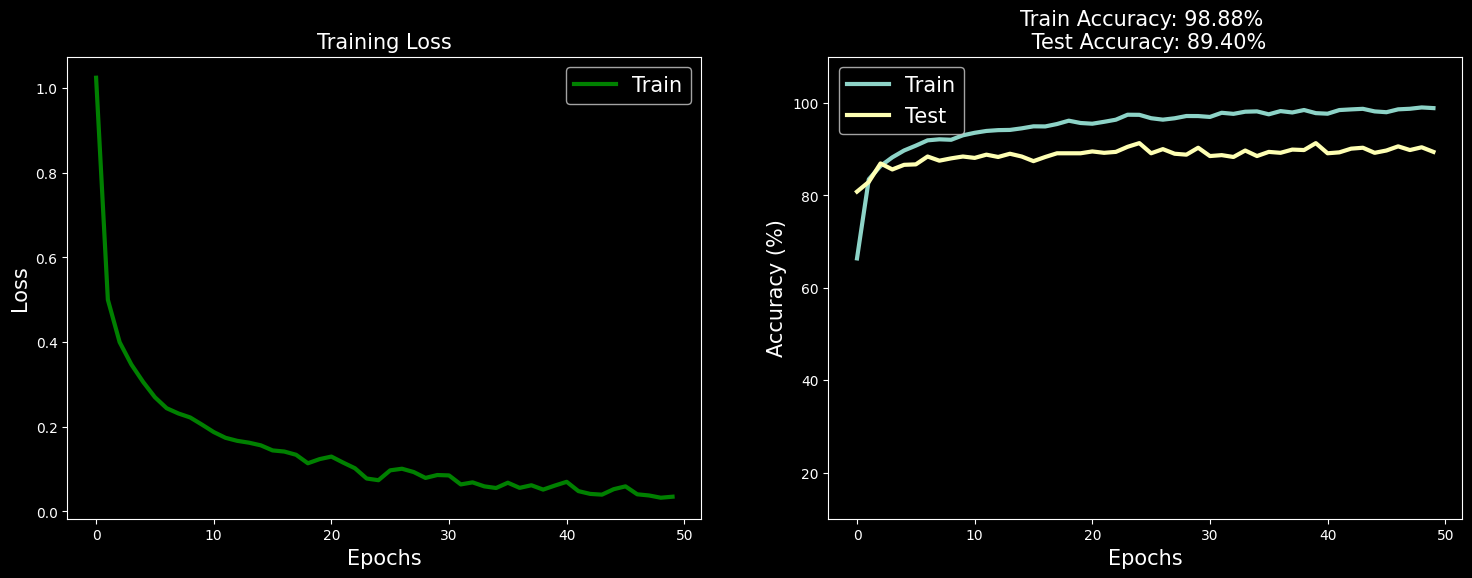

In [13]:
fig,ax = plt.subplots(1,2,figsize=(18,6))

ax[0].plot(hist.history['loss'], 'g', lw = 3, label = 'Train')
ax[0].set_xlabel('Epochs', fontsize = 15)
ax[0].set_ylabel('Loss', fontsize = 15)
ax[0].legend(fontsize = 15)
ax[0].set_title('Training Loss', fontsize = 15)


ax[1].plot(trainAcc, label ='Train', lw = 3)
ax[1].plot(testAcc, label ='Test', lw = 3)
ax[1].set_xlabel('Epochs', fontsize = 15)
ax[1].set_ylabel('Accuracy (%)', fontsize = 15)
ax[1].set_ylim([10,110])
ax[1].set_title(f'Train Accuracy: {trainAcc[-1]:.2f}% \n Test Accuracy: {testAcc[-1]:.2f}%', fontsize = 15)
ax[1].legend(fontsize = 15)

plt.show()